In [1]:
from datasets import load_dataset

# Load dataset 1
ds1 = load_dataset("cnamuangtoun/resume-job-description-fit")
print(ds1)

ds2 = load_dataset("AzharAli05/Resume-Screening-Dataset")
print(ds2)

train.csv:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 6241
    })
    test: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 1759
    })
})


README.md:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

dataset.csv:   0%|          | 0.00/34.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10174 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Role', 'Resume', 'Decision', 'Reason_for_decision', 'Job_Description'],
        num_rows: 10174
    })
})


Train set shape: (6241, 3)
Test set shape: (1759, 3)

Label distribution in Train Set:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64


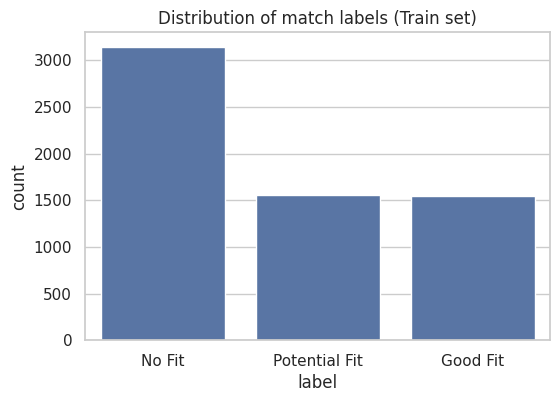

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#set plot style
sns.set_theme(style="whitegrid")

# convert huggingface dataset to pandas dataframe
df_train = ds1['train'].to_pandas()
df_test = ds1['test'].to_pandas()

print(f"Train set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

# check the distribution of labels
print("\nLabel distribution in Train Set:")
print(df_train['label'].value_counts(dropna=False))

# plot the distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_train, x='label')
plt.title("Distribution of match labels (Train set)")
plt.show()

Resume Word count stats: 
count    6241.000000
mean      708.056722
std       391.724444
min        84.000000
50%       618.000000
75%       810.000000
90%      1153.000000
95%      1591.000000
max      3134.000000
Name: resume_word_count, dtype: float64

Job Description word count stats: 
count    6241.000000
mean      371.546387
std       239.142971
min        11.000000
50%       328.000000
75%       532.000000
90%       695.000000
95%       810.000000
max      1079.000000
Name: jd_word_count, dtype: float64


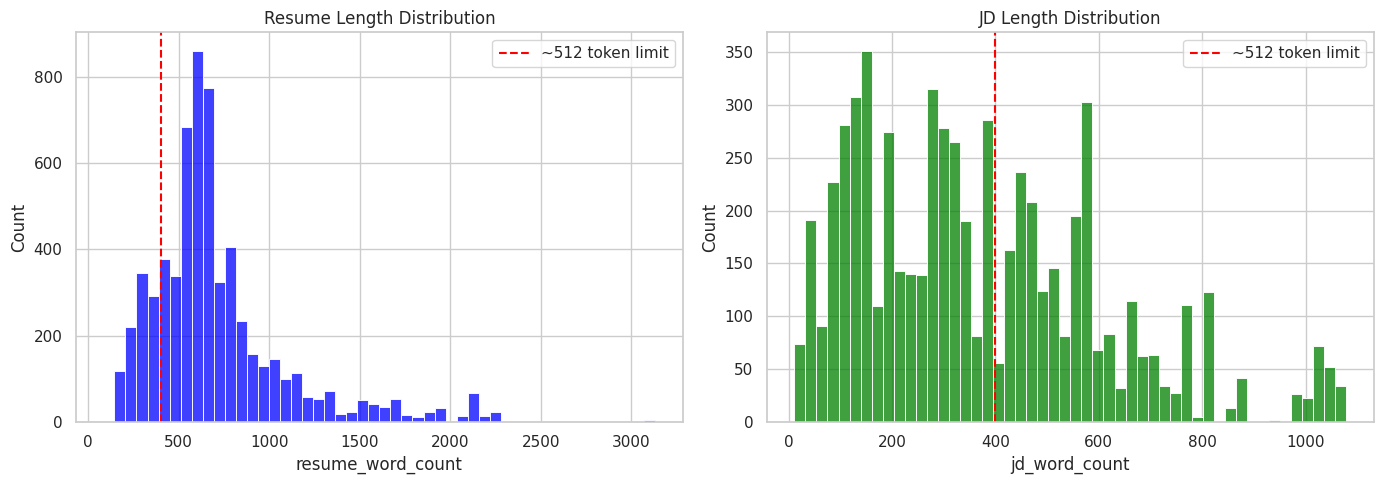

In [3]:
# Calculate the approximate word counts (splitting by whitespace is a good proxy for tokens)
df_train['resume_word_count'] = df_train['resume_text'].apply(lambda x: len(str(x).split()))
df_train['jd_word_count'] = df_train['job_description_text'].apply(lambda x:len(str(x).split()))

# Print summary stats
print("Resume Word count stats: ")
print(df_train['resume_word_count'].describe(percentiles=[0.50,0.75,0.90,0.95]))

print("\nJob Description word count stats: ")
print(df_train['jd_word_count'].describe(percentiles=[0.50,0.75,0.90,0.95]))

# Plot the distributions
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df_train['resume_word_count'],bins = 50, ax = ax[0],color='blue')
ax[0].set_title('Resume Length Distribution')
ax[0].axvline(400, color='red',linestyle='--',label='~512 token limit')
ax[0].legend()

sns.histplot(df_train['jd_word_count'],bins = 50, ax = ax[1], color='green')
ax[1].set_title('JD Length Distribution')
ax[1].axvline(400,color='red',linestyle='--',label = '~512 token limit')
ax[1].legend()

plt.tight_layout()
plt.show()

In [4]:
# Convert ds2 to Pandas
df_backup = ds2['train'].to_pandas()

print("Backup Dataset Info:")
print(df_backup.info())

print("\nFirst 3 rows:")
display(df_backup.head(3))

# If there is a category/label column, let's see it
if 'Category' in df_backup.columns or 'label' in df_backup.columns:
    target_col = 'Category' if 'Category' in df_backup.columns else 'label'
    print(f"\nDistribution of {target_col}:")
    print(df_backup[target_col].value_counts().head(10))

Backup Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Role                 10174 non-null  object
 1   Resume               10174 non-null  object
 2   Decision             10174 non-null  object
 3   Reason_for_decision  10174 non-null  object
 4   Job_Description      10174 non-null  object
dtypes: object(5)
memory usage: 397.6+ KB
None

First 3 rows:


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,Game Developer,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,Human Resources Specialist,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...


In [ ]:
import os

linkedin_path = '/kaggle/input/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/linkedin_job_postings.csv' # Update this based on the print output!

try:
    # We might only want to load a chunk first since 1.3M rows is huge and might crash the RAM
    df_linkedin = pd.read_csv(linkedin_path, nrows=100000) 
    print(f"\nSuccessfully loaded {len(df_linkedin)} rows from LinkedIn dataset.")
    display(df_linkedin.head())
    
    # Check if a 'skills' column exists
    skills_cols = [c for c in df_linkedin.columns if 'skill' in c.lower()]
    print(f"\nPotential skills columns found: {skills_cols}")
    
except FileNotFoundError:
    print("\nFile path incorrect. Please copy the correct path from the printed list above.")

In [5]:
# Map text labels to match numerical scores
label_mapping = {
    'No Fit': 0.0,
    'Potential Fit': 0.5,
    'Good Fit': 1.0
}

df_train['score'] = df_train['label'].map(label_mapping)
df_test['score'] = df_test['label'].map(label_mapping)

print("Numeric score mapping:")
print(df_train['score'].value_counts(dropna=False))

Numeric score mapping:
score
0.0    3143
0.5    1556
1.0    1542
Name: count, dtype: int64


In [6]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords',quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()
    # Remove special characters and numbers (keep basic punctuation for sentence structure)
    text = re.sub(r'[^a-z\s\.\,]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

# Apply to a small sample first to check
sample_resume = df_train['resume_text'].iloc[0]
cleaned_sample = clean_text(sample_resume)

print(f"Original Length: {len(sample_resume.split())} words")
print(f"Cleaned Length: {len(cleaned_sample.split())} words")
print(f"Reduction: {100 - (len(cleaned_sample.split()) / len(sample_resume.split()) * 100):.1f}%")

Original Length: 794 words
Cleaned Length: 596 words
Reduction: 24.9%


In [7]:
skills_path = '/kaggle/input/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/job_skills.csv' 

try:
    # Load the skills dataset
    df_skills = pd.read_csv(skills_path)
    print(f"Successfully loaded {len(df_skills)} rows from job_skills.csv")
    
    print("\nColumns:")
    print(df_skills.columns.tolist())
    
    print("\nFirst 5 rows:")
    display(df_skills.head())
    
    # If the column containing the actual skill is named 'skill_abr' or similar, let's find the top 20
    # We will guess the column is named 'skill_abr' based on common kaggle linkedin datasets. 
    # If it's named something else, we will see it in the print output above.
    skill_col = [col for col in df_skills.columns if 'skill' in col.lower()][0]
    
    print(f"\nTop 20 most frequent skills in {skill_col}:")
    print(df_skills[skill_col].value_counts().head(20))
    
    print(f"\nTotal UNIQUE skills: {df_skills[skill_col].nunique()}")
    
except FileNotFoundError:
    print(f"File not found at {skills_path}. Please check the exact path.")

Successfully loaded 1296381 rows from job_skills.csv

Columns:
['job_link', 'job_skills']

First 5 rows:


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."



Top 20 most frequent skills in job_skills:
job_skills
Front Counter, DriveThru, Outside Order Taker, Runner, Dining Room Attendant, Drinks, Make Up Table, Prep, Grill, Fry, Porter, Coaching, High school diploma/GED, Restaurant leadership experience, Food Handlers Certification                                                                                                                                                 169
Front Counter, DriveThru, Outside Order Taker, Runner, Dining Room Attendant, Drinks, Make Up Table, Prep, Grill, Fry, Porter, Coaching, High school diploma/GED, 1+ years of restaurant leadership experience, Food Handlers Certification                                                                                                                                     112
Communication, Collaboration, Holds Self Accountable, Solution Oriented, People Centric, Relevant, Initiative, Deliver, Evolve                                                                           

In [8]:
# 1. Drop missing values and take a sample for speed during EDA
df_skills_clean = df_skills.dropna(subset=['job_skills']).copy()
sample_skills = df_skills_clean['job_skills'].head(100000)

# 2. Split the strings by comma, and 'explode' them so each skill gets its own row
individual_skills = sample_skills.str.split(',').explode()

# 3. Clean the text: lowercase, remove leading/trailing whitespace
individual_skills = individual_skills.astype(str).str.lower().str.strip()

# 4. Filter out noise: remove empty strings, and remove strings that are too long to be a real skill (like that weird sentence we saw)
# A typical skill is usually less than 40 characters
individual_skills = individual_skills[individual_skills.str.len() > 1]
individual_skills = individual_skills[individual_skills.str.len() < 40]
# Filter out common noise phrases
noise_phrases = ["this context does not mention", "none found"]
individual_skills = individual_skills[~individual_skills.str.contains('|'.join(noise_phrases))]

# 5. Count the true frequencies!
top_individual_skills = individual_skills.value_counts()

print(f"Total True UNIQUE skills in sample: {len(top_individual_skills)}")
print("\nTop 30 Most Frequent Individual Skills:")
print(top_individual_skills.head(30))

Total True UNIQUE skills in sample: 376422

Top 30 Most Frequent Individual Skills:
job_skills
communication             27315
customer service          22872
teamwork                  18401
communication skills      16049
attention to detail       12859
problem solving           11927
time management           11703
leadership                11143
problemsolving            10077
project management         9357
interpersonal skills       7573
organizational skills      6485
multitasking               6272
collaboration              6091
high school diploma        6019
microsoft office suite     5952
sales                      5892
data analysis              5565
training                   5371
patient care               5335
adaptability               5323
inventory management       5066
flexibility                5009
scheduling                 4979
troubleshooting            4851
microsoft office           4778
bachelor's degree          4462
analytical skills          4384
organizat

In [9]:
from itertools import combinations
from collections import Counter

# 1. Create a vocabulary of just the Top 1,000 skills
vocab = set(top_individual_skills.head(1000).index)

# 2. Initialize a counter for our edges
co_occurrences = Counter()

# 3. Iterate over our sample jobs to build the graph edges
print("Building Graph Edges (this may take 10-20 seconds)...")
for skill_string in sample_skills.head(50000):  # Using 50k jobs to build the prototype graph
    # Clean and split the skills for this specific job
    skills_in_job = [s.strip().lower() for s in str(skill_string).split(',')]
    
    # Filter out skills that aren't in our Top 1000 vocabulary
    valid_skills = [s for s in skills_in_job if s in vocab]
    
    # Create pairs (edges) for every skill connected to every other skill in this job
    for pair in combinations(valid_skills, 2):
        # Sort alphabetically so (Python, SQL) is the same as (SQL, Python)
        pair = tuple(sorted(pair))
        co_occurrences[pair] += 1

print("\nSuccess! Graph Edges generated.")
print(f"Total unique connections (edges): {len(co_occurrences)}")

print("\nTop 20 Strongest Skill Connections (Edges for your GAT):")
for pair, count in co_occurrences.most_common(20):
    print(f"{pair[0]} <---> {pair[1]}: Weight = {count}")

Building Graph Edges (this may take 10-20 seconds)...

Success! Graph Edges generated.
Total unique connections (edges): 241244

Top 20 Strongest Skill Connections (Edges for your GAT):
communication <---> customer service: Weight = 5875
communication <---> teamwork: Weight = 5525
customer service <---> teamwork: Weight = 4132
communication <---> problem solving: Weight = 3826
communication <---> problemsolving: Weight = 3465
communication <---> time management: Weight = 3351
attention to detail <---> communication: Weight = 3243
communication <---> leadership: Weight = 3138
attention to detail <---> teamwork: Weight = 2980
attention to detail <---> customer service: Weight = 2710
customer service <---> problem solving: Weight = 2689
customer service <---> time management: Weight = 2552
teamwork <---> time management: Weight = 2552
problemsolving <---> teamwork: Weight = 2520
communication skills <---> customer service: Weight = 2477
problem solving <---> teamwork: Weight = 2430
attent

In [10]:
# Let's take the Top 500 skills as our official dictionary
skill_dictionary = set(top_individual_skills.head(500).index)

def extract_skills_from_text(text, skill_dict):
    """A fast dictionary-matching skill extractor."""
    if not isinstance(text, str): return []
    text_lower = text.lower()
    
    extracted = []
    # Simple check: is the skill phrase inside the text?
    # (In a production environment, we'd use SpaCy PhraseMatcher or FlashText for speed)
    for skill in skill_dict:
        # Using word boundaries to avoid partial matches (e.g., 'art' matching inside 'earth')
        if re.search(r'\b' + re.escape(skill) + r'\b', text_lower):
            extracted.append(skill)
    return extracted

# Test it on the first 5 resumes in our training data
print("Testing Skill Extraction on Resumes:")
for i in range(5):
    sample_res = df_train['resume_text'].iloc[i]
    found_skills = extract_skills_from_text(sample_res, skill_dictionary)
    
    print(f"\n--- Resume {i+1} (Label: {df_train['label'].iloc[i]}) ---")
    print(f"Total Skills Found: {len(found_skills)}")
    print(f"Skills: {', '.join(found_skills)}")

Testing Skill Extraction on Resumes:

--- Resume 1 (Label: No Fit) ---
Total Skills Found: 47
Skills: life insurance, excel, billing, ms excel, writing, quality assurance, microsoft office, quality, business, forecasting, safety, audit, sales experience, training, team building, retail, food safety, staffing, public speaking, troubleshooting, accounts receivable, supervision, operations, maintenance, reports, ms office, accounts payable, management, cpa, accounting software, payroll, budgeting, customer service, retail sales, networking, project management, windows, insurance, merchandising, logistics, planning, reporting, driving, education, sales, accounting, procedures

--- Resume 2 (Label: No Fit) ---
Total Skills Found: 31
Skills: programming, testing, implementation, communication, specifications, quality, business, technology, safety, travel, interpersonal skills, sustainability, training, engineering, equipment, master's degree, electrical, maintenance, research, management, ef

In [11]:
import json

# 1. Save the cleaned training and testing data
df_train.to_csv('/kaggle/working/train_clean.csv', index=False)
df_test.to_csv('/kaggle/working/test_clean.csv', index=False)

# 2. Save the top 500 skill dictionary
with open('/kaggle/working/skill_vocab.json', 'w') as f:
    json.dump(list(skill_dictionary), f)

# 3. Save the Graph Edges (Convert Counter to a list of dicts for easy saving)
edges_to_save = [{"source": pair[0], "target": pair[1], "weight": weight} 
                 for pair, weight in co_occurrences.items()]
                 
with open('/kaggle/working/graph_edges.json', 'w') as f:
    json.dump(edges_to_save, f)

print("All data artifacts saved successfully to /kaggle/working/!")

All data artifacts saved successfully to /kaggle/working/!
